# Tutorial: Train 2D Classifier
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> Updated Aug. 2025: use mlinphysics module
> Harrison B. Prosper<br>
> Updated Tue Sep 08 2026: HBP, use updated Monitor<br>
> Updated Wed Sep 16 2026: HBP, add exercises


## Introduction

In this tutorial, we build a simple classifier, $f_\boldsymbol{\omega}(\boldsymbol{x})$, to classify the points in a 2D dataset sampled from a **mixture model** comprising two overlapping densities each modeled as a multivariate normal (that is, Gaussian) density,
\begin{align}
\mathcal{N}(x, \mu, \Sigma) & = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2} } \exp\left(-\tfrac{1}{2} z^T \Sigma^{-1} z \right),
\end{align}
where
\begin{align}
    x & = \begin{bmatrix}
            x_1 \\ x_2
            \end{bmatrix}, \quad
    \mu  = \begin{bmatrix}
            \mu_1 \\ \mu_2
            \end{bmatrix}, \quad
    z  = \begin{bmatrix}
            x_1 - \mu_1 \\ x_2 - \mu_2
            \end{bmatrix},\\
    \Sigma & = \begin{bmatrix}
        \Sigma_{11} & \Sigma_{12}\\
        \Sigma_{21} & \Sigma_{22}
    \end{bmatrix},
\end{align}
with the following mean and covariance matrices,
\begin{align}
    \color{blue}{\text{\bf Class } y = 1} &\nonumber\\
    \mu & = \begin{pmatrix} 0.25 &  -0.25\end{pmatrix},\\
    \Sigma & = \begin{pmatrix}
                    0.20 & 0.24 \\ 
                    0.24 & 0.40
                \end{pmatrix},\\
    \color{red}{\text{\bf Class } y = 0} &\nonumber\\
    \mu & = \begin{pmatrix}-0.10 &  0.10\end{pmatrix},\\
    \Sigma & = \begin{pmatrix}
                    0.60 & 0.40 \\ 
                    0.40 & 0.30
                \end{pmatrix} .
\end{align}

The best-fit values, $\widehat{\omega}$, of the classifier parameters are found by  minimizing the **empirical risk** $R(\omega)$ (aka **average loss**). The **binary cross entropy loss** (a special case of the **cross entropy loss** for classification into more than two classes, and discussed in a later tutorial) is the standard loss for building a binary (that is, 2-class) classifier. 

The binary cross entropy loss is defined by 

$$L(y, f) = - [y \log f + (1 - y) \log(1-f)],$$ 

with the discrete targets $y \in \{0, 1\}$. In Lecture 2, it is shown that the best-fit function $f_\widehat{\boldsymbol{\omega}}(\boldsymbol{x})$ approximates the solution,  $f_{\boldsymbol{\omega}^*}(\boldsymbol{x})$, to the equation
\begin{align*}
\mathbb{E}_{p(y \mid \boldsymbol{x})}\left[ \frac{\partial L(y, f)}{\partial f} \right] & = 0, \\
\int \, \frac{\partial L(y, f)}{\partial f} \, p(y \mid \boldsymbol{x}) \, dy & = 0,
\end{align*}
where $L(y, f)$ can be any (piece-wise) differentiable loss function.

From
\begin{align*}
0 & = \int \, \frac{\partial L(y, f)}{\partial f} \, p(y \mid \boldsymbol{x}) \, dy, \quad \text{ we see that}\\
    & = \int \,  \left[ \frac{y}{f} - \frac{(1 - y)}{1-f}  \right] p(y \mid \boldsymbol{x}) \, dy,\\
    & = \frac{p(1 \mid \boldsymbol{x})}{f} - \frac{p(0 \mid \boldsymbol{x})}{1 -f},\\
   \frac{f}{1-f} & = \frac{p(1 \mid \boldsymbol{x})}{p(0 \mid \boldsymbol{x})},\quad \implies f  = p(1 \mid \boldsymbol{x}) ,
\end{align*}
that is, our classifier approximates the probability that an object characterized by the **feature** vector $\boldsymbol{x}$ belongs to the class labeled by $y = 1$. This conclusion is independent of the details of the model $f_\boldsymbol{\omega}(\boldsymbol{x})$. But it does require the latter to have sufficient **capacity**, that is, ability to approximate $f_{\boldsymbol{\omega}^*}(\boldsymbol{x})$ and that the minimizer can find a good approximation of the minimum of the risk functional, $R[f]$, by using its approximation, $R(\omega)$. 

In [1]:
# standard system modules
import os, sys, re

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

# ML in Physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

# use for reloading modules that have been imported
import importlib

# module for shell utilities
import shutil

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": shutil.which('latex') is not None, 
    "font.family": "sans-serif",
    "font.size": FONTSIZE
})

## Density of data, $m(x)$
**Notation**
\begin{align}
    p_1(x) & \equiv p(x \mid 1), & \quad\text{density of points in class labeled $y = 1$},\\
    p_0(x) & \equiv p(x \mid 0), & \quad\text{density of points in class labeled $y = 0$},\\
    \pi    & \equiv \pi(1),      & \quad\text{prior probability of class labeled $y = 1$},\\
    1 - \pi & \equiv \pi(0),     & \quad\text{prior probability of class labeled $y = 0$}.
\end{align}
Then we can write the probability density of the data as $$m(x) = p_1(x) \, \pi + p_0(x) \,(1 - \pi)$$ and the classifier $C_\pi(x)$, approximated by $f_\widehat{\omega}(x)$, as
$$C_\pi(x) = \frac{p_1(x) \, \pi}{m(x)}.$$

For a **balanced** data set $\pi \equiv \pi(1) = 1/2$. (When there is a possibility of confusion between the number $\pi$ and the prior $\pi$, we'll revert to the notation $\pi(1)$  for the latter.)

Use the `%%writefile` magic command to write the cell contents to a file. The contents of file can then be imported into another notebook. 

In [3]:
%%writefile exactdensity.py
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
# -----------------------------------------------------------
class ExactDensity:
    
    def __init__(self):
        # Class y = 1
        self.rv1 = st.multivariate_normal(mean=[0.25, -0.25], 
                                          cov=[[0.20, 0.24], 
                                               [0.24, 0.40]])
        # Class y = 0
        self.rv2 = st.multivariate_normal(mean=[-0.10, 0.10], 
                                          cov=[[0.60, 0.40], 
                                               [0.40, 0.30]])

    def generate(self, filename=None, 
                 N1=50_000, N0=50_000, 
                 rng=np.random.default_rng(12345), 
                 as_dataframe=False):
        '''
        Note: if filename given save to a csv file
        N1: int     number of points from class y = 1
        N0: int     number of points from class y = 0
        '''
        d1 = self.rv1.rvs(N1, random_state=rng)
        d2 = self.rv2.rvs(N0, random_state=rng)
        
        ones = np.ones(N1)[:, np.newaxis]
        dd1  = np.hstack([d1, ones])  # stack horizontally

        zeros= np.zeros(N0)[:, np.newaxis]
        dd2  = np.hstack([d2, zeros])
        
        dd = np.vstack([dd1, dd2])    # stack vertically
        np.random.shuffle(dd.astype(np.float32))

        # save as csv file if filename given
        df = None
        if filename != None:
            # first convert to dataframe
            df = pd.DataFrame(dd, columns=['x1', 'x2', 'y'])
            df.to_csv(filename, index=False)

        # return as a dataframe if requested,
        # otherwise return a numpy array.
        if as_dataframe:
            if df is None:
                df = pd.DataFrame(dd, columns=['x1', 'x2', 'y'])
            return df
        else:
            return dd
        
    def grid(self, flatten=False, xmin=-1, xmax=1, ymin=-1, ymax=1, N=40):
        xstep = (xmax-xmin)/N
        ystep = (ymax-ymin)/N
        x1, x2 = np.mgrid[xmin:xmax+xstep/2:xstep, ymin:ymax+ystep/2:ystep]
        if flatten:
            x1 = x1.flatten()
            x2 = x2.flatten()
        return x1, x2
        
    def __call__(self, x1, x2):
        # compute density at a grid of (x1, x2) points
        pos= np.dstack((x1, x2))
        p1 = self.rv1.pdf(pos)
        p0 = self.rv2.pdf(pos)
        return (p1 + p0)/2

    def prob(self, x1, x2):
        # compute p(y=1|x) at a grid of (x1, x2) points
        pos= np.dstack((x1, x2))
        p1 = self.rv1.pdf(pos)
        p0 = self.rv2.pdf(pos)
        return p1 / (p1 + p0)

    def plot(self, papprox=None, dataframe=None,
            xmin=-1, xmax=1, ymin=-1, ymax=1, fgsize=(4, 4)):
        x1, x2 = self.grid()
        
        fig = plt.figure(figsize=fgsize)
        ax  = fig.add_subplot(111)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        
        tickmarks = [-1.0, -0.5, 0.0, 0.5, 1.0]
        ax.set_xticks(tickmarks)
        ax.set_yticks(tickmarks)
        
        # plot p(x)
        plot_approx = type(papprox) != type(None)
        if not plot_approx:
            ax.contourf(x1, x2, self(x1, x2))

        if type(dataframe) != type(None):
            df = dataframe
            K = 1000
            try:
                xp, yp, _ = df[df.y > 0.5].to_numpy().T
            except:
                y = df[:, -1]
                xp, yp, _ = df[y > 0.5].T
            ax.scatter(xp[:K], yp[:K], s=0.8, color='cyan')

            try:
                xp, yp, _ = df[df.y < 0.5].to_numpy().T
            except:
                y = df[:, -1]
                xp, yp, _ = df[y < 0.5].T
            ax.scatter(xp[:K], yp[:K], s=0.8, color='red')

        # plot p(1|x)
        levels = np.arange(0.1, 1.0, 0.2) # values of p(1|x)
        pexact = self.prob(x1, x2)
        ax.contour(x1, x2, pexact, levels=levels, 
                   cmap='rainbow_r', linestyles='solid')

        if plot_approx:
            ax.contour(x1, x2, papprox, levels=levels, 
                       cmap='rainbow_r', linestyles='dashed')

        ax.grid()
        fig.tight_layout()
        plt.show()

Overwriting exactdensity.py


## Plot exact data density

  1. Plot $m(x)$
  2. Superimpose contours of constant $p(1 \mid x) = p_1(x) \, \pi / m(x)$

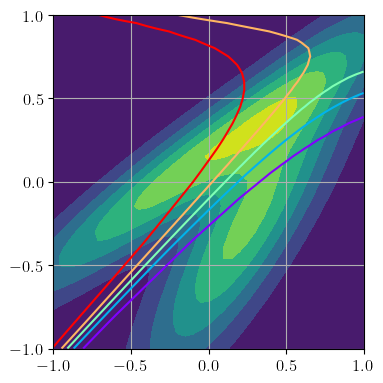

In [4]:
import exactdensity as dn
importlib.reload(dn)

fexact = dn.ExactDensity()
fexact.plot()

## Load data $x \sim m(x)$
Half of the points in the dataset are tagged with $y = 1$ (the $\color{blue}{\text{blue points}}$) and the other half are tagged with class label $y = 0$ (the red points), that is, the data set is balanced.


	load generated data



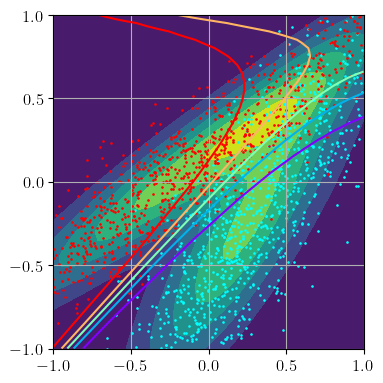

100000


array([[ 0.00825074, -0.2343391 ,  1.        ],
       [ 1.05618   ,  0.7173787 ,  1.        ],
       [ 0.70971453,  0.29195255,  1.        ],
       [-1.1967161 , -0.41583166,  0.        ],
       [-0.06933062,  0.18416029,  0.        ],
       [-0.86176485, -0.2618514 ,  0.        ],
       [ 1.2515634 ,  1.0241003 ,  0.        ],
       [-1.1046221 , -0.72277826,  0.        ],
       [ 0.71528804,  0.77296245,  0.        ],
       [ 0.5577657 ,  0.5480894 ,  0.        ]], dtype=float32)

In [5]:
generate_data = False

data_file = '../data/two2dnormals.csv'

if generate_data:
    print('\n\tgenerate data\n')
    data = fexact.generate(filename=data_file)
else:
    print('\n\tload generated data\n')
    data = pd.read_csv(data_file).to_numpy().astype(np.float32)
    
fexact.plot(dataframe=data)

print(len(data))

data[:10]

## Training configuration

In [6]:
# computational device
# -----------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

# name of model
# -----------------------------------------
name = 'gauss2d'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    # load configuration
    config = mlp.Config(f'runs/{name}/{name}.yaml')
    
    # training configuration
    # -----------------------------------------
    train_size = config('train_size')         # training sample size
    test_size  = config('test_size')          # test sample size 
    val_size   = config('val_size')           # validation sample size 
    batch_size = config('batch_size')
    monitor_step = config('monitor_step')     # monitor training every n (=10) iterations
    
    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    n_steps = config('n_steps')               # number of training steps
    n_iters_per_step = config('n_iters_per_step')
    n_iterations = n_iters_per_step * n_steps # number of iterations
    
    base_lr = config('base_lr')               # initial learning rate
    gamma   = config('gamma')                 # learning rate scale factor
else:
    # create new configuration
    config = mlp.Config(name, dirname=name)
    
    # training configuration
    # -----------------------------------------
    train_size = config('train_size', 80_000) # training sample size
    test_size  = config('test_size',  18_000) # test sample size 
    val_size   = config('val_size',    2_000) # validation sample size 
    batch_size = config('batch_size',    256)
    monitor_step = config('monitor_step',100) # monitor training every n iterations
    
    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    n_steps = config('n_steps', 1)                   # number of training steps
    n_iters_per_step = config('n_iters_per_step', 50_000)
    n_iterations = n_iters_per_step * n_steps        # number of iterations
    
    config('n_iterations', n_iterations)
    config('frac', 0.005)   # save model if loss reduces by this fraction
    
    base_lr = config('base_lr', 1.e-4)               # initial learning rate
    gamma   = config('gamma', 0.5)                   # learning rate scale factor
    
    print(f'\nSave configuration to file {config.cfg_filename}\n')
    config.save()

print(config)

Available device: cpu 

Save configuration to file runs/gauss2d/gauss2d_config.yaml

name: gauss2d
file:
  losses: runs/gauss2d/gauss2d_losses.csv
  params: runs/gauss2d/gauss2d_params.pth
  script: runs/gauss2d/gauss2d_script.pth
  init_params: runs/gauss2d/gauss2d_init_params.pth
  plots: runs/gauss2d/gauss2d_plots.png
train_size: 80000
test_size: 18000
val_size: 2000
batch_size: 256
monitor_step: 100
n_steps: 1
n_iters_per_step: 50000
n_iterations: 50000
frac: 0.005
base_lr: 0.0001
gamma: 0.5



## Create Datasets

Split data into inputs $\boldsymbol{x}$ and targets $y$.

In [7]:
# training dataset (this defines the empirical risk to be minimized)
train_data = dat.Dataset(data, 
                         start=0, 
                         end=train_size, 
                         split_col=2) # [0, 1], [2]

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
train_data_val = dat.Dataset(data, 
                             start=0, 
                             end=train_size,
                             random_sample_size=val_size,
                             split_col=2) # [0, 1], [2]

# validation dataset (for monitoring training)
val_data = dat.Dataset(data, 
                       start=train_size, 
                       end=train_size + val_size,
                       split_col=2)

# test dataset
test_data= dat.Dataset(data, 
                       start=train_size + val_size, 
                       end=train_size + val_size + test_size,
                       split_col=2)

Dataset
  shape of x: torch.Size([80000, 2])
  shape of y: torch.Size([80000, 1])

Dataset
  shape of x: torch.Size([2000, 2])
  shape of y: torch.Size([2000, 1])

Dataset
  shape of x: torch.Size([2000, 2])
  shape of y: torch.Size([2000, 1])

Dataset
  shape of x: torch.Size([18000, 2])
  shape of y: torch.Size([18000, 1])



## Save test data

In [8]:
import joblib
joblib.dump(test_data, '../data/test_data.pth')

['../data/test_data.pth']

## Create DataLoaders

In [9]:
train_loader = dat.DataLoader(train_data, 
                              batch_size=batch_size,
                              num_iterations=n_iterations)

train_loader_val = dat.DataLoader(train_data_val, 
                                  batch_size=len(train_data_val))

val_loader = dat.DataLoader(val_data, 
                            batch_size=len(val_data))

DataLoader
  Number of iterations has been specified
  maxiter:           50000
  batch_size:          256
  shuffle_step:        312

DataLoader
  maxiter:               1
  batch_size:         2000
  shuffle_step:          1

DataLoader
  maxiter:               1
  batch_size:         2000
  shuffle_step:          1



## Define a fully-connected neural network

Use %%writefile to write the network structure to a file.

In [10]:
%%writefile gauss2d.py
import torch
import torch.nn as nn

class Gauss2D(nn.Module):
    
    def __init__(self, hidden=2): 

        # Initialize base (parent) class
        super().__init__()
        
        H = hidden
        self.net = nn.Sequential(
            nn.Linear(2, H), nn.Tanh(), 
            nn.Linear(H, 1), nn.Sigmoid())

    def save(self, paramsfile):
        # save parameters of neural network
        torch.save(self.state_dict(), paramsfile)

    def load(self, paramsfile):
        # load parameters of neural network and set to eval mode
        self.load_state_dict(torch.load(paramsfile, 
                                        weights_only=True,
                                        map_location=torch.device('cpu')))
        self.eval()

    def forward(self, x):
        return self.net(x)

model = Gauss2D()

Overwriting gauss2d.py


## Instantiate training objects
  1. `model`
  2. `objective`
  3. `optimizer`
  4. `scheduler`
  5. `monitor`

In [11]:
import gauss2d
importlib.reload(gauss2d)

model = gauss2d.model.to(DEVICE)

# use Binary Cross Entropy loss 
objective = mlp.Objective(model, nn.BCELoss())

# use standard Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=base_lr) 

# instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma')
)

# instantiate object that saves average losses to
# a csv file for realtime monitoring
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params'))

print(model)
print('number of parameters', mlp.number_of_parameters(model))

number of milestones:          0

Step | Milestone | LR
-----------------------------
   0 |         0 | 1.0e-04   
-----------------------------

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
number of parameters 9


## Train model

In [12]:
def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader):

    # -----------------------------
    # training loop
    # -----------------------------
    for x, y in train_loader:

        # set mode to training so that training-specific 
        # operations such as dropout, etc., are enabled.
        objective.train()

        # clear all gradients
        optimizer.zero_grad()

        # compute empirical risk
        R = objective(x, y)
        
        # compute gradient
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        scheduler.step()

        # I'm alive printout
        if monitor.step():
            
            t_loss = mlp.compute_avg_loss(objective, train_small_loader)
            
            v_loss = mlp.compute_avg_loss(objective, val_loader)

            # return current learning rate
            lr = scheduler.lr()

            # update loss file / save model
            monitor(t_loss, v_loss, lr)

In [13]:
TRAIN = True

if TRAIN:

    monitor.start()

    train(objective, optimizer, scheduler, monitor,
          train_loader, train_loader_val, val_loader)

monlosses runs/gauss2d/gauss2d_losses.csv

		learning rate:  1.000e-04
     49900| 99.80%|00:00:16|00:00:00|3074.0 it/s|2.625e-01|2.659e-01|     49900|

In [14]:
if TRAIN:
    monitor.terminate()


	Terminating standalone loss monitor...
	Done!


## Test model
### Load parameters

In [15]:
model.load(config('file/params'))
print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
number of parameters 9


### Compute exact and approximate classifiers

In [16]:
# Define a couple of one-line functions

# 1. flatten x1 and x2
# 2. stack column-wise
# 3. convert to 32-bit float
# 3. convert to tensor
flatten_x = lambda x1, x2: torch.tensor(
    np.stack([x1.flatten(), x2.flatten()], axis=1).astype(np.float32))

# 1. detach()   - detach from computational tree
# 2. cpu()      - move to CPU if tensor is not on a CPU, e.g., on GPU
# 3. numpy()    - convert to numpy array (ndarray)
fapprox = lambda x: model(x).detach().cpu().numpy()

In [17]:
# exact calculation
x1, x2 = fexact.grid()
pexact = fexact.prob(x1, x2)
print('pexact.shape\t', pexact.shape)

# approximate calculation
x = flatten_x(x1, x2)
print('x.shape \t', x.shape)

papprox = fapprox(x).reshape(pexact.shape) # reshape output of model to match that of pexact
print('papprox.shape\t', papprox.shape)


pexact.shape	 (101, 101)
x.shape 	 torch.Size([10201, 2])
papprox.shape	 (101, 101)


## Exercises

 1. Consider the model you've just trained $$f_\omega(x) = \sigma( \tanh(x A^T_0 + b_0)\,A^T_1  + b_1), \quad \omega = A_0, b_0, A_1, b_1,$$ where, for a single point, $x$ can be viewed as a matrix with a *single* row. For a model of this form with $d$ inputs, $H$ hidden nodes, and a single output, derive a formula for the dimensionality of the parameter space, that is, the number of parameters.  Use your formula to confirm  the dimensionality of the parameter space of your model.
 2. Consider the symmetries of the model, that is, the  different ways of writing the model that are equivalent, that is, which give the same answer. Derive a formula for the number of equivalemt ways of writing the model. *Hint*: consider a graphical representation of the model.
 3. Suppose we had used the quadratic loss (`MSELoss`) instead of the binary cross entropy loss (`BCELoss`). The risk functional would be
    \begin{align}
     R[f] & = \mathbb{E}_{p(x, y)}\left[(y - f)^2 \right], \\
          & = \mathbb{E}_{p(x)}\left[ \, \mathbb{E}_{p(y \mid x)}\left[(y - f)^2 \right] \, \right].
    \end{align}
    Specializing to $y \in \{0, 1\}$ collapses the expectation with respect to $p(y \mid x)$ to two terms, yielding
        \begin{align}
     R[f] & = \mathbb{E}_{p(x)}\left[ \, p(1 \mid x)\,(1 - f)^2 + \, p(0 \mid x)\,f^2\right],\\
        & = \mathbb{E}_{p(x)}\left[ \, C(x) \,(1 - f)^2 + \, [1 - C(x)]\,f^2\right].
    \end{align}
    Show that the above can be expressed as
        \begin{align}
     R[f] & = \mathbb{E}_{p(x)}\left[ \,(C - f)^2 \right] + 
        \mathbb{E}_{p(x)}\left[ \, C \,(1 - C) \, \right].
    \end{align}        

In [18]:
print('parameter\t shape')
for name, param in model.named_parameters(): 
    print(name,'\t', param.shape)

parameter	 shape
net.0.weight 	 torch.Size([2, 2])
net.0.bias 	 torch.Size([2])
net.2.weight 	 torch.Size([1, 2])
net.2.bias 	 torch.Size([1])


## Exercises (contd.)
 4. Write code to approximate $\min R[f] = \mathbb{E}_{p(x)}\left[ \, C \,(1 - C) \, \right]$ using $C \approx f_\widehat{\omega}(x)$.
 5. Then rerun the training with different numbers of hidden nodes $H$ and plot $\min R[f]$ versus $H$.